In [86]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

# Timestamps (Update these based on your runs)
TS_SCALING = "20260107_211932_SCALING_SNAPSHOT"
TS_DISTRIBUTION = "20260107_210341_DISTRIBUTION_SNAPSHOT"
TS_NSYS = "20260107_214611_SNAPSHOT"
TS_NCU = "20260108_025939"

# Base Paths
BENCHMARK_RESULTS_DIR = Path("benchmark/results")
PROFILING_RESULTS_DIR = Path("profiling/results")
NSYS_DIR = PROFILING_RESULTS_DIR / "nsys" / TS_NSYS
NCU_DIR = PROFILING_RESULTS_DIR / "ncu" / TS_NCU

# ==================== IMPROVED STYLING ====================

# Dimensions for Two-Column Paper
SINGLE_COL_WIDTH = 3.5  # inches
DOUBLE_COL_WIDTH = 7.2  # inches
GOLDEN_RATIO = 1.618

# User Adjustments
CHART_HEIGHT_SCALE = 1.2  # Increase to make charts taller
X_LABEL_ROTATION = 15     # Max rotation in degrees

# Publication-quality styling
sns.set_style("whitegrid", {
    'grid.linestyle': '--',
    'grid.alpha': 0.3,
    'axes.edgecolor': '.2',
    'axes.linewidth': 0.8
})

plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'legend.title_fontsize': 8,
    'figure.titlesize': 10,
    'font.family': 'sans-serif',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'patch.linewidth': 0.6,
    'figure.dpi': 300,
    'savefig.dpi': 300
})

# ==================== COLOR PALETTE ====================

# Professional, colorblind-friendly palette
IMPL_COLORS = {
    'cpu': '#D32F2F',                    # Red
    'optimized-cuda': '#1976D2',         # Blue
    'sparse-cuda': '#7B1FA2',            # Purple
    
    # Naive MPI
    'naive-cuda-mpi:linear': '#FBC02D',  # Yellow
    'naive-cuda-mpi:louvain': '#757575', # Gray
    'naive-cuda-mpi:red-blue': '#00ACC1', # Cyan
    
    # Optimized MPI
    'optimized-cuda-mpi:linear': '#388E3C',   # Green
    'optimized-cuda-mpi:louvain': '#F57C00',  # Orange
    'optimized-cuda-mpi:red-blue': '#5D4037', # Brown
}

# Component colors
COMPONENT_COLORS = {
    'CUDA Kernel': '#1976D2',
    'CUDA Memory': '#7B1FA2',
    'MPI': '#F57C00'
}

# Functionality colors
FUNC_COLORS = {
    'Neuron Dynamics': '#1976D2',
    'Propagation': '#D32F2F',
    'MPI Communication': '#388E3C',
    'Maintenance': '#757575',
    'Other': '#FBC02D'
}

# Memory hierarchy colors (fast to slow)
MEM_COLORS = {
    'L1 Cache': '#388E3C',      # Green (fast)
    'L2 Cache': '#F57C00',      # Orange
    'Global Memory': '#D32F2F'  # Red (slow)
}

print("✓ Configuration loaded")

✓ Configuration loaded


In [87]:
# ==================== DATA LOADING UTILITIES ====================

def load_benchmark_data(timestamp):
    """Parse Google Benchmark JSON output."""
    json_path = BENCHMARK_RESULTS_DIR / timestamp / "data.json"
    if not json_path.exists():
        print(f"⚠ Benchmark file not found: {json_path}")
        return pd.DataFrame()
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    records = []
    for bench in data['benchmarks']:
        name = bench['name']
        parts = name.split('/')
        
        if len(parts) >= 3:
            impl = parts[0]
            dist = parts[1]
            try:
                size = int(parts[2])
            except ValueError:
                size = 0
            
            records.append({
                'Implementation': impl,
                'Distribution': dist,
                'Size': size,
                'RealTime': bench['real_time'],
                'TimeUnit': bench.get('time_unit', 'ns'),
                'RunType': bench.get('run_type', 'iteration')
            })
            
    df = pd.DataFrame(records)
    
    if not df.empty:
        def to_ms(row):
            t, u = row['RealTime'], row['TimeUnit']
            if u == 'ns': return t / 1e6
            if u == 'us': return t / 1e3
            if u == 'ms': return t
            if u == 's': return t * 1e3
            return t
        
        df['TimeMS'] = df.apply(to_ms, axis=1)
        
    return df


def load_nsys_summary(impl_name, rank=0):
    """Load Nsys profiling summary."""
    base = NSYS_DIR / impl_name
    
    metrics = {'CUDA Kernel': 0, 'CUDA Memory': 0, 'MPI': 0}
    
    # GPU metrics
    gpu_files = list(base.glob(f"*rank{rank}*stats_cuda_api_gpu_sum.csv"))
    if not gpu_files:
        gpu_files = list(base.glob("*stats_cuda_api_gpu_sum.csv"))
    
    if gpu_files:
        try:
            df_gpu = pd.read_csv(gpu_files[0])
            metrics['CUDA Kernel'] = df_gpu[df_gpu['Category'] == 'CUDA_KERNEL']['Total Time (ns)'].sum()
            metrics['CUDA Memory'] = df_gpu[df_gpu['Category'] == 'MEMORY_OPER']['Total Time (ns)'].sum()
        except Exception:
            pass
    
    # MPI metrics
    mpi_files = list(base.glob(f"*rank{rank}*stats_mpi_event_sum.csv"))
    if not mpi_files:
        mpi_files = list(base.glob("*stats_mpi_event_sum.csv"))
    
    if mpi_files:
        try:
            df_mpi = pd.read_csv(mpi_files[0])
            metrics['MPI'] = df_mpi['Total Time (ns)'].sum()
        except Exception:
            pass
    
    return metrics


print("✓ Data loading utilities ready")

✓ Data loading utilities ready


---
## Figure 1: Scaling Performance (Speedup vs CPU)

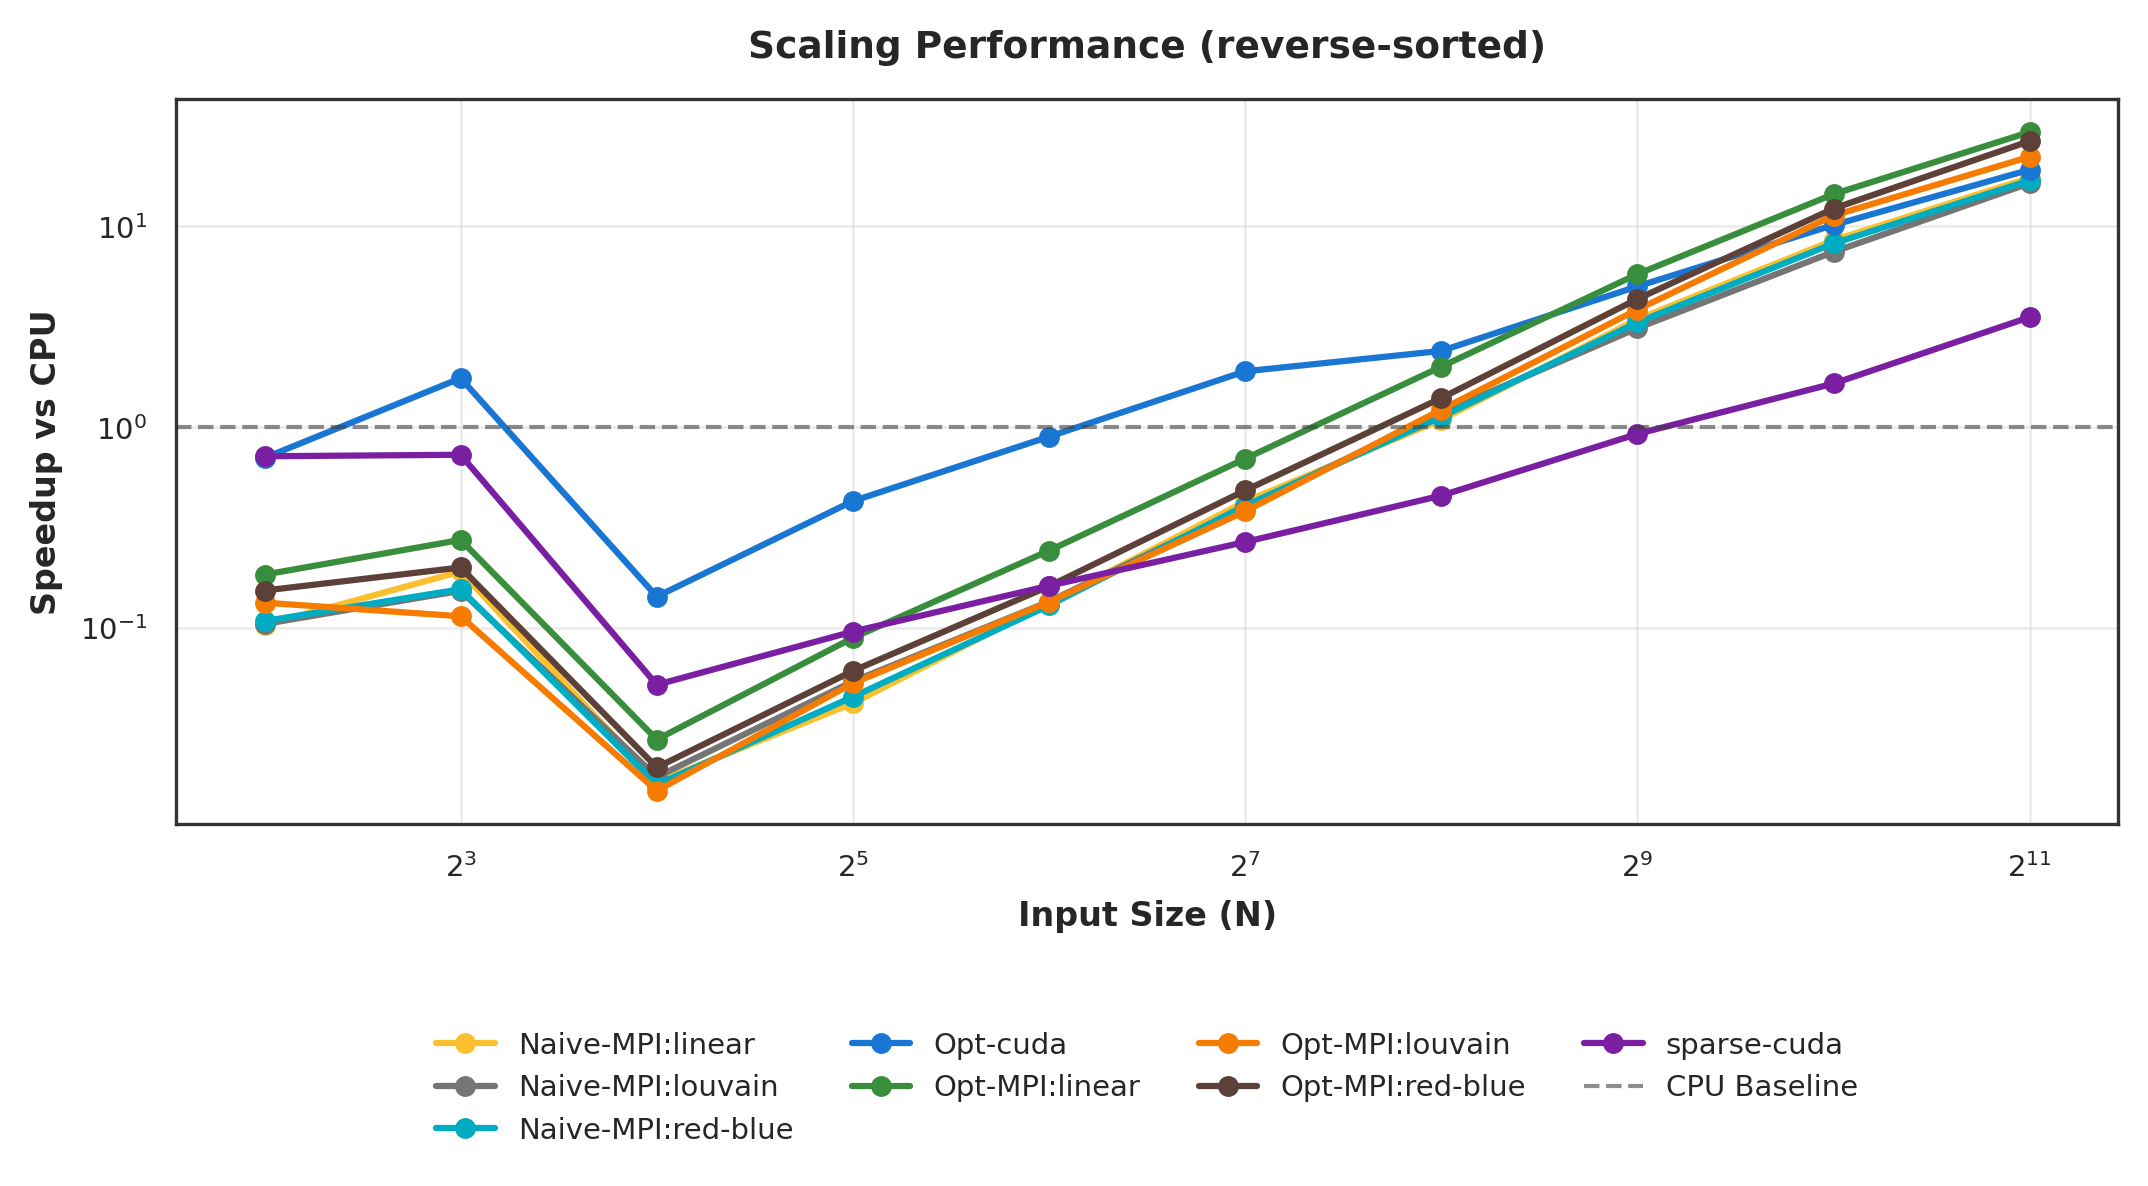

In [88]:
df_scale = load_benchmark_data(TS_SCALING)

if not df_scale.empty:
    target_dist = 'reverse-sorted'
    subset = df_scale[
        (df_scale['Distribution'] == target_dist) & 
        (df_scale['RunType'] == 'iteration')
    ].copy()
    
    if subset.empty:
        print(f"⚠ No data for '{target_dist}', using all available")
        subset = df_scale[df_scale['RunType'] == 'iteration'].copy()
        target_dist = 'all'
        
    # Calculate speedup vs CPU
    cpu_times = subset[subset['Implementation'] == 'cpu'].groupby('Size')['TimeMS'].mean()
    
    if not cpu_times.empty:
        subset['CPU_Time'] = subset['Size'].map(cpu_times)
        subset['Speedup'] = subset['CPU_Time'] / subset['TimeMS']
        
        # Aggregate by mean
        plot_data = subset.groupby(['Implementation', 'Size'])['Speedup'].mean().reset_index()
        
        # Create figure - DOUBLE COLUMN
        fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.5 * CHART_HEIGHT_SCALE))
        
        # Plot each implementation
        # Filter to keep plot readable if too many lines
        priority_impls = ['optimized-cuda', 'sparse-cuda', 'optimized-cuda-mpi:louvain', 'naive-cuda-mpi:linear']
        
        for impl in plot_data['Implementation'].unique():
            if impl == 'cpu': continue
            
            # Simple filtering logic if we have too many, or just plot all
            # For now, plot all but maybe style priority ones differently? 
            # Or just plot all as scaling usually needs comparison.
            
            impl_data = plot_data[plot_data['Implementation'] == impl]
            color = IMPL_COLORS.get(impl, '#333333')
            
            # Simplify label
            label = impl.replace('cuda-mpi', 'MPI').replace('optimized', 'Opt').replace('naive', 'Naive')
            
            ax.plot(impl_data['Size'], impl_data['Speedup'], 
                   marker='o', color=color, label=label, linewidth=1.5, markersize=4)
        
        # Baseline
        ax.axhline(1, color='#424242', linestyle='--', alpha=0.6, linewidth=1.0, 
                  label='CPU Baseline')
        
        # Styling
        ax.set_xscale('log', base=2)
        ax.set_yscale('log')
        ax.set_xlabel('Input Size (N)', fontweight='bold')
        ax.set_ylabel('Speedup vs CPU', fontweight='bold')
        ax.set_title(f'Scaling Performance ({target_dist})', 
                    pad=10, fontweight='bold')
        
        ax.grid(True, which='major', alpha=0.4, linestyle='-', linewidth=0.6)
        
        # Legend inside or below? Below for 2-col usually better to save vertical space?
        # Or right side. Let's put it below.
        ax.legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', frameon=False,
                 ncol=4)
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ No CPU baseline found")
else:
    print("⚠ No scaling data available")

---
## Figure 2: Distribution Stability Analysis

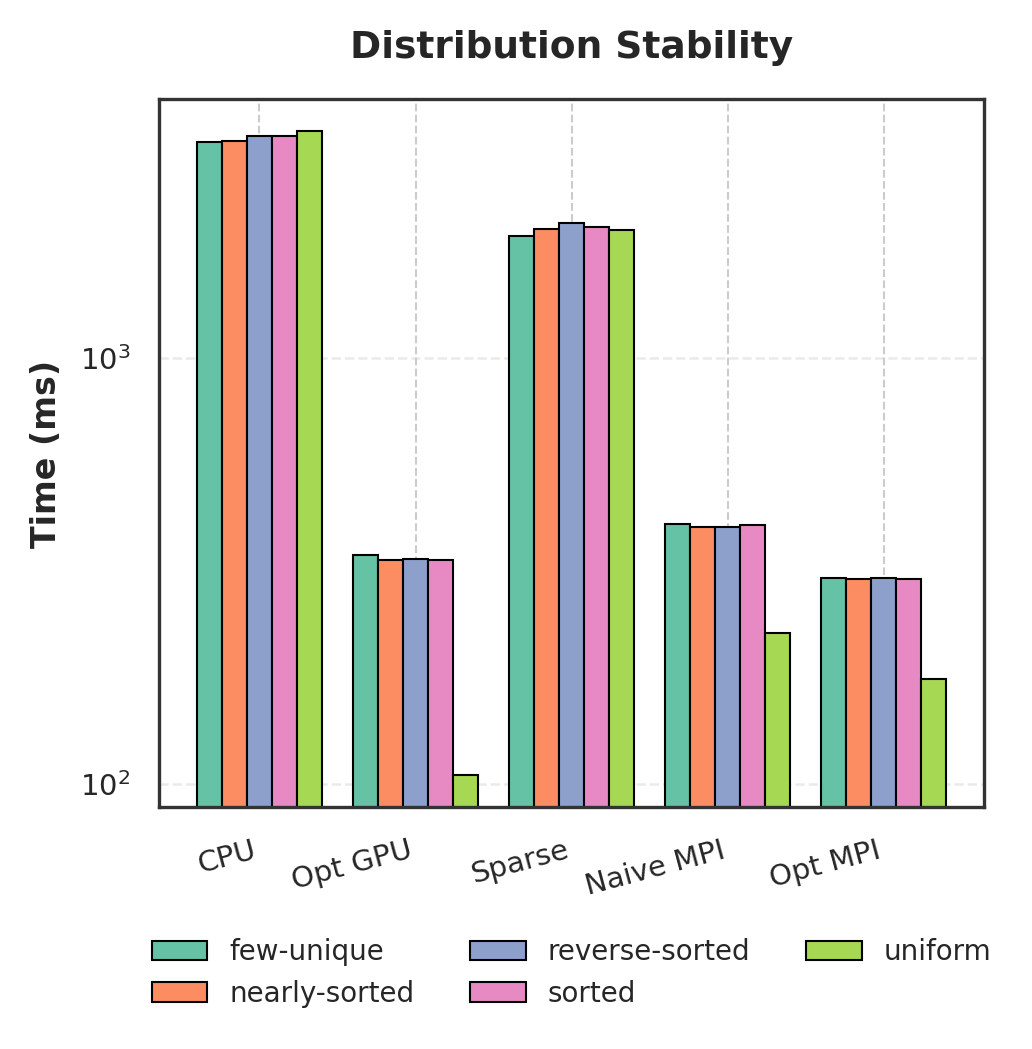

In [ ]:
df_dist = load_benchmark_data(TS_DISTRIBUTION)

if not df_dist.empty:
    common_sizes = df_dist['Size'].mode()
    if not common_sizes.empty:
        target_size = common_sizes[0]
        subset = df_dist[
            (df_dist['Size'] == target_size) &
            (df_dist['RunType'] == 'iteration')
        ].copy()
        
        # Filter implementations to reduce clutter for SINGLE COLUMN
        # We keep CPU, Opt-CUDA, Sparse, and the Best MPI (Opt-Louvain) and Baseline MPI (Naive-Linear)
        keep_impls = [
            'cpu', 
            'optimized-cuda', 
            'sparse-cuda',
            'naive-cuda-mpi:linear',
            'optimized-cuda-mpi:louvain'
        ]
        subset = subset[subset['Implementation'].isin(keep_impls)]
        
        # Shorten implementation names for labels
        name_map = {
            'cpu': 'CPU',
            'optimized-cuda': 'Opt GPU',
            'sparse-cuda': 'Sparse',
            'naive-cuda-mpi:linear': 'Naive MPI',
            'optimized-cuda-mpi:louvain': 'Opt MPI'
        }
        
        # Aggregate to mean
        plot_data = subset.groupby(['Implementation', 'Distribution'])['TimeMS'].mean().reset_index()
        
        # Create figure - SINGLE COLUMN
        fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 3 * CHART_HEIGHT_SCALE))
        
        # Get unique values
        distributions = sorted(plot_data['Distribution'].unique())
        implementations = [i for i in keep_impls if i in plot_data['Implementation'].unique()] # Preserve order
        
        x = np.arange(len(implementations))
        width = 0.8 / len(distributions)
        
        # Use a nice color palette for distributions
        dist_colors = sns.color_palette("Set2", len(distributions))
        
        # Plot grouped bars
        for i, dist in enumerate(distributions):
            dist_data = plot_data[plot_data['Distribution'] == dist]
            values = [dist_data[dist_data['Implementation'] == impl]['TimeMS'].values[0] 
                     if impl in dist_data['Implementation'].values else 0 
                     for impl in implementations]
            
            offset = (i - len(distributions)/2 + 0.5) * width
            ax.bar(x + offset, values, width, label=dist, 
                  color=dist_colors[i], edgecolor='black', linewidth=0.5)
        
        ax.set_ylabel('Time (ms)', fontweight='bold')
        ax.set_title('Distribution Stability', pad=10, fontweight='bold')
        
        ax.set_xticks(x)
        ax.set_xticklabels([name_map.get(i, i) for i in implementations], 
                          rotation=X_LABEL_ROTATION, ha='right')
        
        ax.grid(axis='y', alpha=0.4, linewidth=0.6)
        ax.set_yscale('log') # Log scale often helps if CPU is included
        
        # Legend
        ax.legend(title=None, bbox_to_anchor=(0.5, -0.15), 
                 loc='upper center', frameon=False, ncol=3,
                 fontsize='small')
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ Could not determine common size")
else:
    print("⚠ No distribution data available")

---
## Figure 3: Execution Time Breakdown (Profiling)

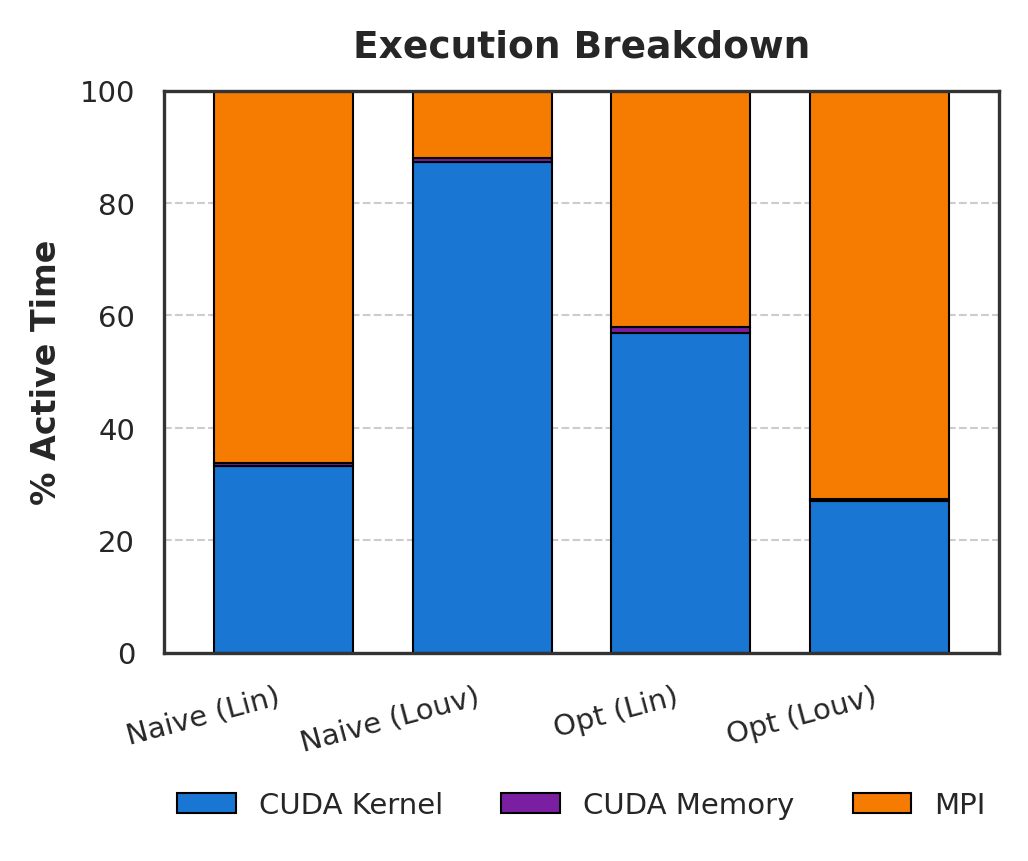

In [90]:
nsys_impls = [
    'naive-cuda-mpi-linear',
    'naive-cuda-mpi-louvain',
    'optimized-cuda-mpi-linear',
    'optimized-cuda-mpi-louvain',
]
# Removed red-blue and variants to fit column

breakdown_data = []

for impl in nsys_impls:
    stats = load_nsys_summary(impl, rank=0)
    if stats['CUDA Kernel'] > 0 or stats['MPI'] > 0:
        breakdown_data.append({
            'Implementation': impl,
            'CUDA Kernel': stats['CUDA Kernel'] / 1e9,
            'CUDA Memory': stats['CUDA Memory'] / 1e9,
            'MPI': stats['MPI'] / 1e9
        })

if breakdown_data:
    df_nsys = pd.DataFrame(breakdown_data)
    df_nsys.set_index('Implementation', inplace=True)
    
    # Shorten names
    short_names = {
        'naive-cuda-mpi-linear': 'Naive (Lin)',
        'naive-cuda-mpi-louvain': 'Naive (Louv)',
        'optimized-cuda-mpi-linear': 'Opt (Lin)',
        'optimized-cuda-mpi-louvain': 'Opt (Louv)',
    }
    df_nsys.rename(index=short_names, inplace=True)
    
    # Calculate percentages
    df_pct = df_nsys.div(df_nsys.sum(axis=1), axis=0) * 100
    
    # Create figure - SINGLE COLUMN
    fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 2.5 * CHART_HEIGHT_SCALE))
    
    # Stacked bar chart
    df_pct.plot(kind='bar', stacked=True, ax=ax,
               color=[COMPONENT_COLORS['CUDA Kernel'], 
                     COMPONENT_COLORS['CUDA Memory'], 
                     COMPONENT_COLORS['MPI']],
               edgecolor='black', linewidth=0.5, width=0.7)
    
    ax.set_xlabel('')
    ax.set_ylabel('% Active Time', fontweight='bold')
    ax.set_title('Execution Breakdown', pad=8, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=X_LABEL_ROTATION, ha='right')
    ax.set_ylim([0, 100])
    
    # Legend
    ax.legend(bbox_to_anchor=(0.5, -0.20), loc='upper center', 
             frameon=False, ncol=3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No profiling data available")

---
## Figure 4: Partitioning Strategy Impact

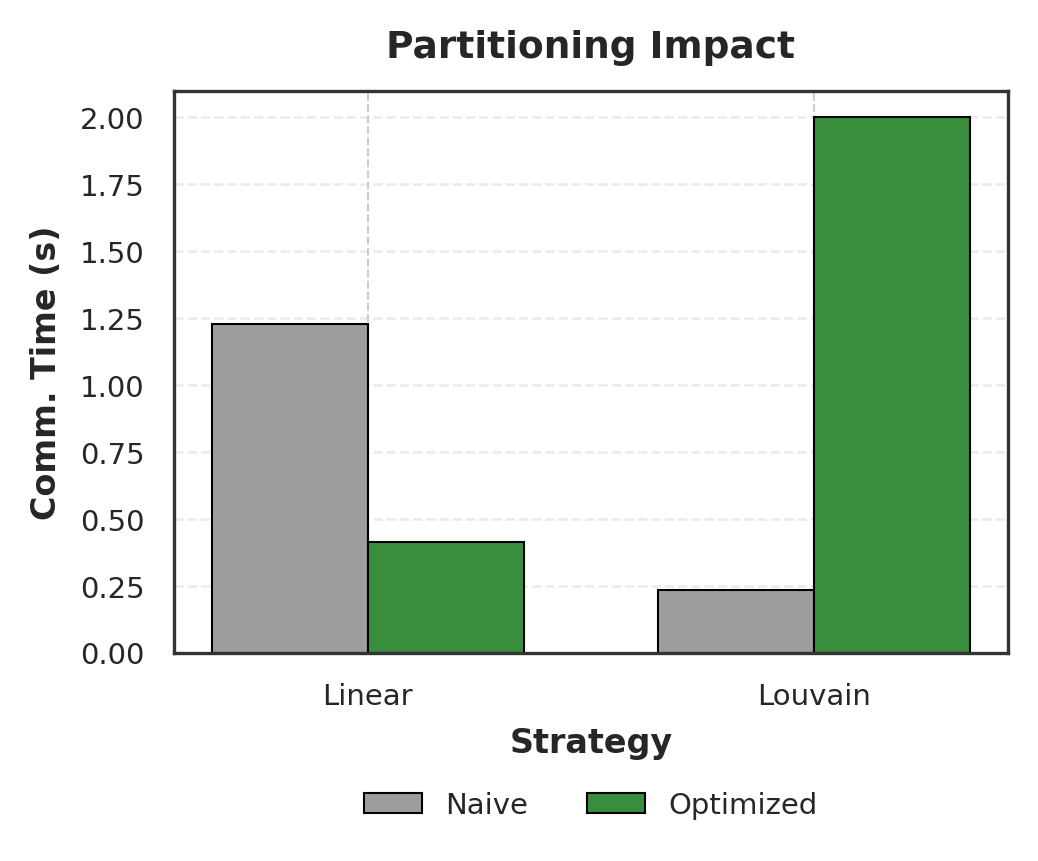

In [91]:
if breakdown_data:
    df_nsys_orig = pd.DataFrame(breakdown_data)
    mpi_df = df_nsys_orig[df_nsys_orig['Implementation'].str.contains('mpi')].copy()
    
    if not mpi_df.empty:
        # Extract variant and strategy
        def parse_impl(name):
            parts = name.split('-')
            variant = parts[0].capitalize()
            # Handle variable length strategies
            if 'red' in parts: strategy = 'Red-Blue'
            elif 'louvain' in parts: strategy = 'Louvain'
            else: strategy = 'Linear'
            return pd.Series([variant, strategy])
        
        mpi_df[['Variant', 'Strategy']] = mpi_df['Implementation'].apply(parse_impl)
        
        # Create figure - SINGLE COLUMN
        fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 2.5 * CHART_HEIGHT_SCALE))
        
        # Grouped bar chart
        strategies = sorted(mpi_df['Strategy'].unique())
        variants = sorted(mpi_df['Variant'].unique())
        
        x = np.arange(len(strategies))
        width = 0.35
        
        variant_colors = {'Naive': '#9E9E9E', 'Optimized': '#388E3C'}
        
        for i, variant in enumerate(variants):
            variant_data = mpi_df[mpi_df['Variant'] == variant]
            # Match strictly
            values = []
            for s in strategies:
                match = variant_data[variant_data['Strategy'] == s]
                if not match.empty:
                    values.append(match['MPI'].values[0])
                else:
                    values.append(0)
            
            offset = (i - 0.5) * width
            ax.bar(x + offset, values, width, label=variant, 
                  color=variant_colors.get(variant, '#333'),
                  edgecolor='black', linewidth=0.5)
        
        ax.set_xlabel('Strategy', fontweight='bold')
        ax.set_ylabel('Comm. Time (s)', fontweight='bold')
        ax.set_title('Partitioning Impact', pad=8, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(strategies, rotation=0) # Short labels rarely need rotation
        ax.grid(axis='y', alpha=0.4, linewidth=0.6)
        
        # Legend
        ax.legend(title=None, bbox_to_anchor=(0.5, -0.20), 
                 loc='upper center', frameon=False, ncol=2)
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ No MPI data found")
else:
    print("⚠ No data for partitioning analysis")

---
## Figure 5: Kernel Functionality Breakdown

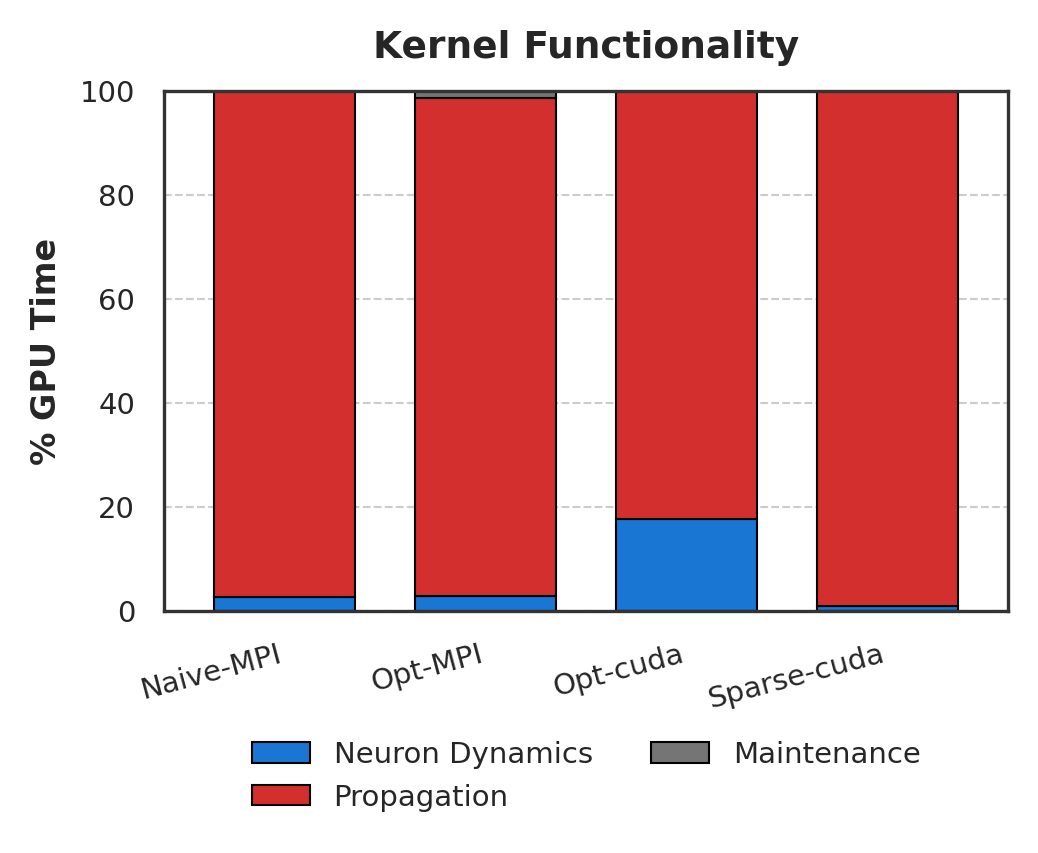

In [92]:
# Kernel to functionality mapping
KERNEL_FUNCTION_MAP = {
    'updateNeuronDynamicsKernel': 'Neuron Dynamics',
    'computeSpikingVectorKernel': 'Neuron Dynamics',
    'propagateSpikesKernel': 'Propagation',
    'propagateLocalSpikesKernel': 'Propagation',
    'consumeSpikesAndProduceKernel': 'Propagation',
    'updateDelaysAndEmitKernel': 'Propagation',
    'populateExportBufferKernel': 'Propagation',
    'applyImportedSpikesKernel': 'Propagation',
    'resetNeuronsKernel': 'Maintenance',
    'clearSpikeProductionKernel': 'Maintenance',
    'initializeKernel': 'Maintenance'
}

target_impls = [
    'optimized-cuda',
    'sparse-cuda',
    'naive-cuda-mpi-linear',
    'optimized-cuda-mpi-linear'
]

kernel_data = []

for impl in target_impls:
    metrics_path = NCU_DIR / impl / "snp_profile_metrics.csv"
    if not metrics_path.exists():
        candidates = list((NCU_DIR / impl).glob("*rank0_metrics.csv"))
        if candidates:
            metrics_path = candidates[0]
        else:
            continue
    
    try:
        # Parse time unit - simplified logic
        # Assuming we can just read the file
        df = pd.read_csv(metrics_path, header=0, skiprows=[1])
        # Find unit in raw file if needed, but for relative % it doesn't matter much
        # We'll trust values are comparable within file
        
        df.columns = [c.replace('"', '').strip() for c in df.columns]
        df['Kernel Name'] = df['Kernel Name'].str.replace('"', '').str.strip()
        
        def clean_name(name):
            if '(' in name: name = name.split('(')[0]
            if '::' in name: name = name.split('::')[-1]
            return name.strip()
        
        df['CleanName'] = df['Kernel Name'].apply(clean_name)
        df['Functionality'] = df['CleanName'].map(KERNEL_FUNCTION_MAP).fillna('Other')
        df['TimeRaw'] = pd.to_numeric(df['gpu__time_duration.sum'], errors='coerce')
        
        grouped = df.groupby('Functionality')['TimeRaw'].sum()
        
        for func, time_val in grouped.items():
            # Shorten names
            display_name = impl.replace('cuda-mpi', 'MPI').replace('-linear', '')
            display_name = display_name.replace('optimized', 'Opt').replace('naive', 'Naive').replace('sparse', 'Sparse')
            
            kernel_data.append({
                'Implementation': display_name,
                'Functionality': func,
                'Time': time_val
            })
    
    except Exception as e:
        print(f"⚠ Error processing {impl}: {e}")

if kernel_data:
    df_kernel = pd.DataFrame(kernel_data)
    df_pivot = df_kernel.pivot(index='Implementation', columns='Functionality', values='Time').fillna(0)
    df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
    
    # Order columns
    func_order = ['Neuron Dynamics', 'Propagation', 'MPI Communication', 'Maintenance', 'Other']
    cols = [c for c in func_order if c in df_pct.columns]
    df_pct = df_pct[cols]
    
    # Create figure - SINGLE COLUMN
    fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 2.5 * CHART_HEIGHT_SCALE))
    
    df_pct.plot(kind='bar', stacked=True, ax=ax,
               color=[FUNC_COLORS.get(c, '#9E9E9E') for c in df_pct.columns],
               edgecolor='black', linewidth=0.5, width=0.7)
    
    ax.set_xlabel('')
    ax.set_ylabel('% GPU Time', fontweight='bold')
    ax.set_title('Kernel Functionality', pad=8, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=X_LABEL_ROTATION, ha='right')
    ax.set_ylim([0, 100])
    
    # Legend
    ax.legend(title=None, bbox_to_anchor=(0.5, -0.20), 
             loc='upper center', frameon=False, ncol=2)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No kernel data available")

---
## Figure 6: Memory Hierarchy Utilization

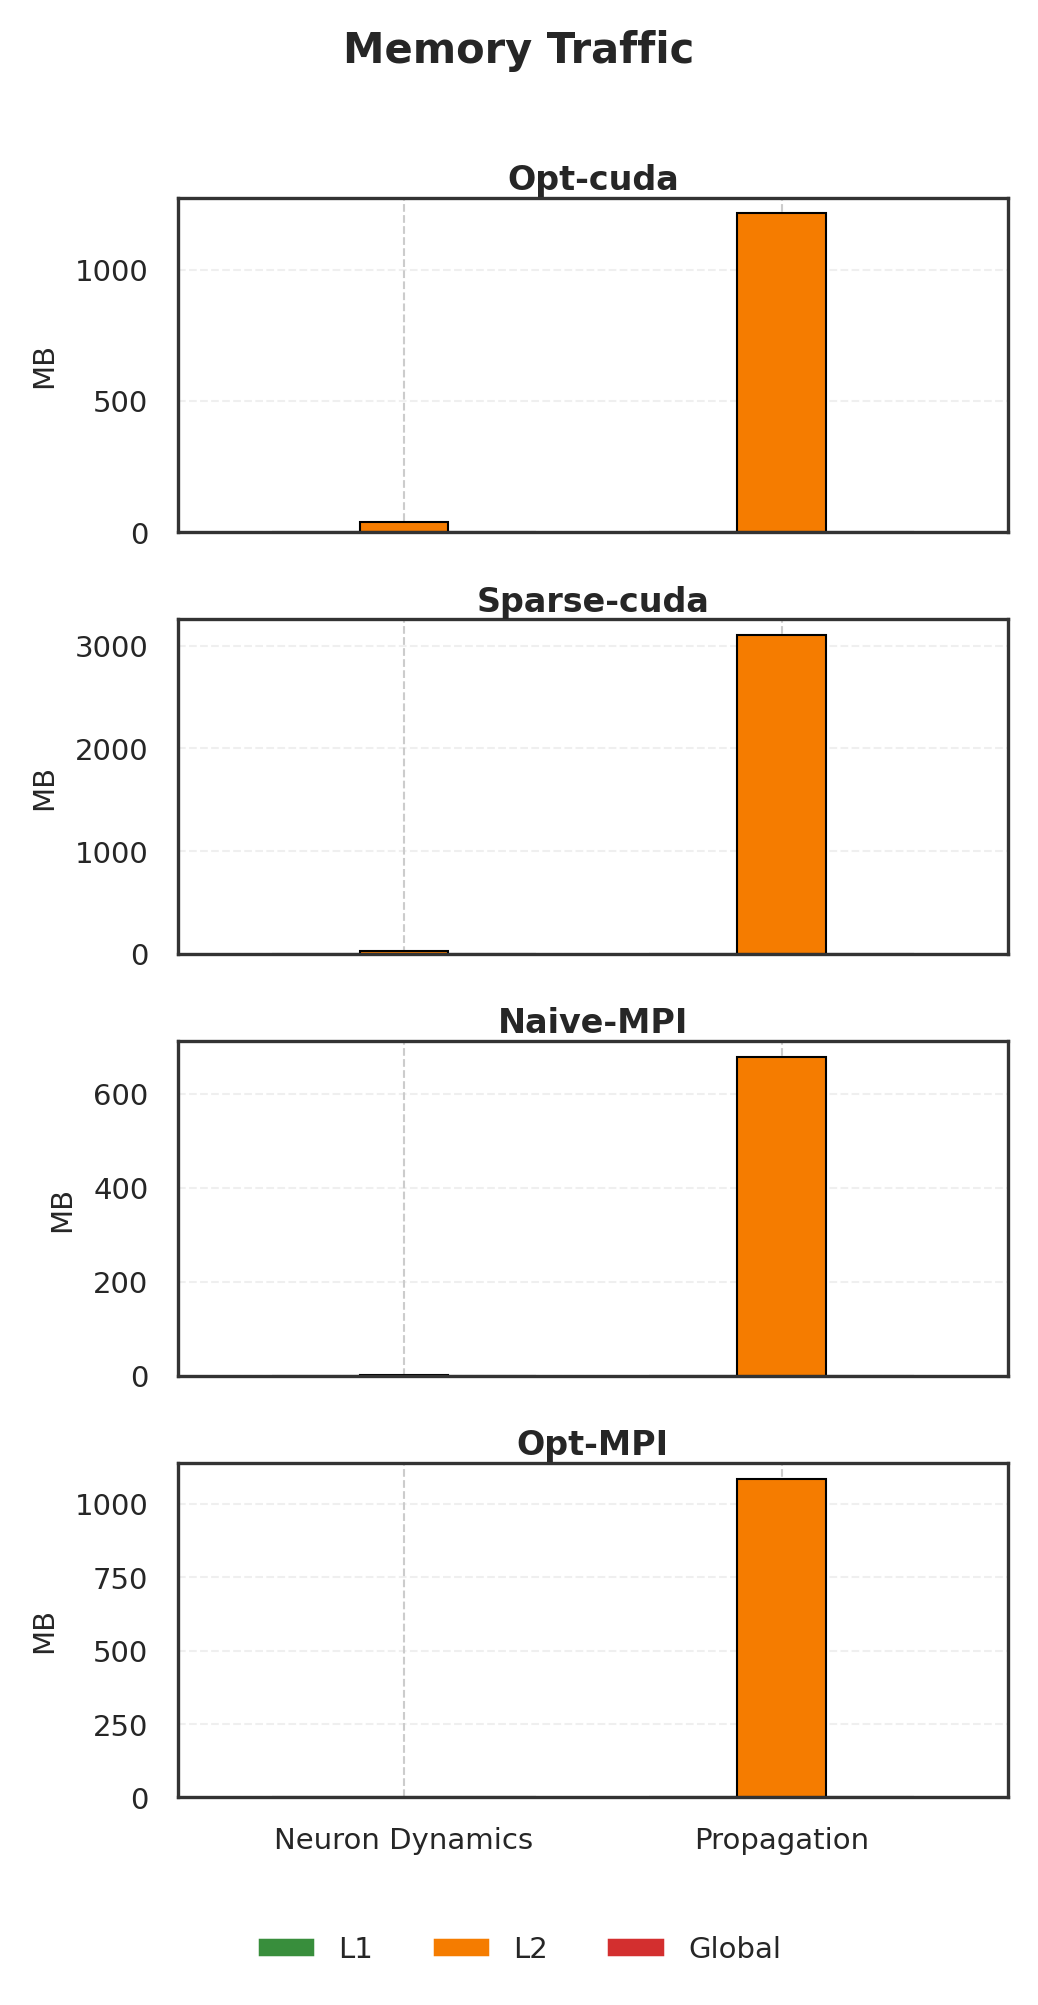

In [93]:
mem_data = []

for impl in target_impls:
    metrics_path = NCU_DIR / impl / "snp_profile_metrics.csv"
    if not metrics_path.exists():
        candidates = list((NCU_DIR / impl).glob("*rank0_metrics.csv"))
        if candidates:
            metrics_path = candidates[0]
        else:
            continue
    
    try:
        df = pd.read_csv(metrics_path, header=0, skiprows=[1])
        df.columns = [c.replace('"', '').strip() for c in df.columns]
        df['Kernel Name'] = df['Kernel Name'].str.replace('"', '').str.strip()
        
        def clean_name(name):
            if '(' in name: name = name.split('(')[0]
            if '::' in name: name = name.split('::')[-1]
            return name.strip()
        
        df['CleanName'] = df['Kernel Name'].apply(clean_name)
        df['Functionality'] = df['CleanName'].map(KERNEL_FUNCTION_MAP).fillna('Other')
        
        # Memory columns
        mem_cols = [
            'dram__bytes_read.sum', 'dram__bytes_write.sum',
            'l1tex__t_bytes_lookup_hit.sum', 'l1tex__t_bytes_lookup_miss.sum',
            'lts__t_sectors_lookup_hit.sum', 'lts__t_sectors_lookup_miss.sum'
        ]
        
        for col in mem_cols:
            if col not in df.columns:
                df[col] = 0
            else:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        group = df.groupby('Functionality')[mem_cols].sum()
        
        for func, row in group.iterrows():
            if func not in ['Neuron Dynamics', 'Propagation', 'MPI Communication']:
                continue
            
            dram_mb = (row['dram__bytes_read.sum'] + row['dram__bytes_write.sum']) / 1e6
            l1_mb = (row['l1tex__t_bytes_lookup_hit.sum'] + row['l1tex__t_bytes_lookup_miss.sum']) / 1e6
            l2_sectors = row['lts__t_sectors_lookup_hit.sum'] + row['lts__t_sectors_lookup_miss.sum']
            l2_mb = (l2_sectors * 32.0) / 1e6
            
            display_name = impl.replace('cuda-mpi', 'MPI').replace('-linear', '')
            display_name = display_name.replace('optimized', 'Opt').replace('naive', 'Naive').replace('sparse', 'Sparse')
            
            mem_data.append({'Implementation': display_name, 'Functionality': func, 
                           'Memory': 'L1 Cache', 'TrafficMB': l1_mb})
            mem_data.append({'Implementation': display_name, 'Functionality': func, 
                           'Memory': 'L2 Cache', 'TrafficMB': l2_mb})
            mem_data.append({'Implementation': display_name, 'Functionality': func, 
                           'Memory': 'Global Memory', 'TrafficMB': dram_mb})
    
    except Exception as e:
        print(f"⚠ Error processing {impl}: {e}")

if mem_data:
    df_mem = pd.DataFrame(mem_data)
    
    implementations = df_mem['Implementation'].unique()
    n_impls = len(implementations)
    
    # Vertical stack for single column width
    # 4 rows, 1 col
    fig, axes = plt.subplots(n_impls, 1, figsize=(SINGLE_COL_WIDTH, 5.5 * CHART_HEIGHT_SCALE), sharex=True)
    if n_impls == 1: axes = [axes]
    
    for idx, impl in enumerate(implementations):
        ax = axes[idx]
        impl_data = df_mem[df_mem['Implementation'] == impl]
        
        pivot = impl_data.pivot(index='Functionality', columns='Memory', values='TrafficMB').fillna(0)
        pivot = pivot[['L1 Cache', 'L2 Cache', 'Global Memory']]
        
        pivot.plot(kind='bar', ax=ax, 
                  color=[MEM_COLORS[c] for c in pivot.columns],
                  edgecolor='black', linewidth=0.5, width=0.7, legend=False)
        
        ax.set_title(impl, fontweight='bold', fontsize=8, pad=2)
        ax.set_xlabel('')
        # Only show ylabel on middle ones? or all? Space is tight.
        ax.set_ylabel('MB', fontsize=7)
        ax.tick_params(axis='x', rotation=0)
        ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    
    # Consolidated legend at bottom
    handles = [plt.Rectangle((0,0),1,1, facecolor=MEM_COLORS[m], edgecolor=None) 
              for m in ['L1 Cache', 'L2 Cache', 'Global Memory']]
    fig.legend(handles, ['L1', 'L2', 'Global'], 
              loc='lower center', bbox_to_anchor=(0.5, 0.0), 
              ncol=3, frameon=False)
    
    fig.suptitle('Memory Traffic', fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    plt.show()
else:
    print("⚠ No memory data available")

---
## Figure 7: Warp Stall Analysis

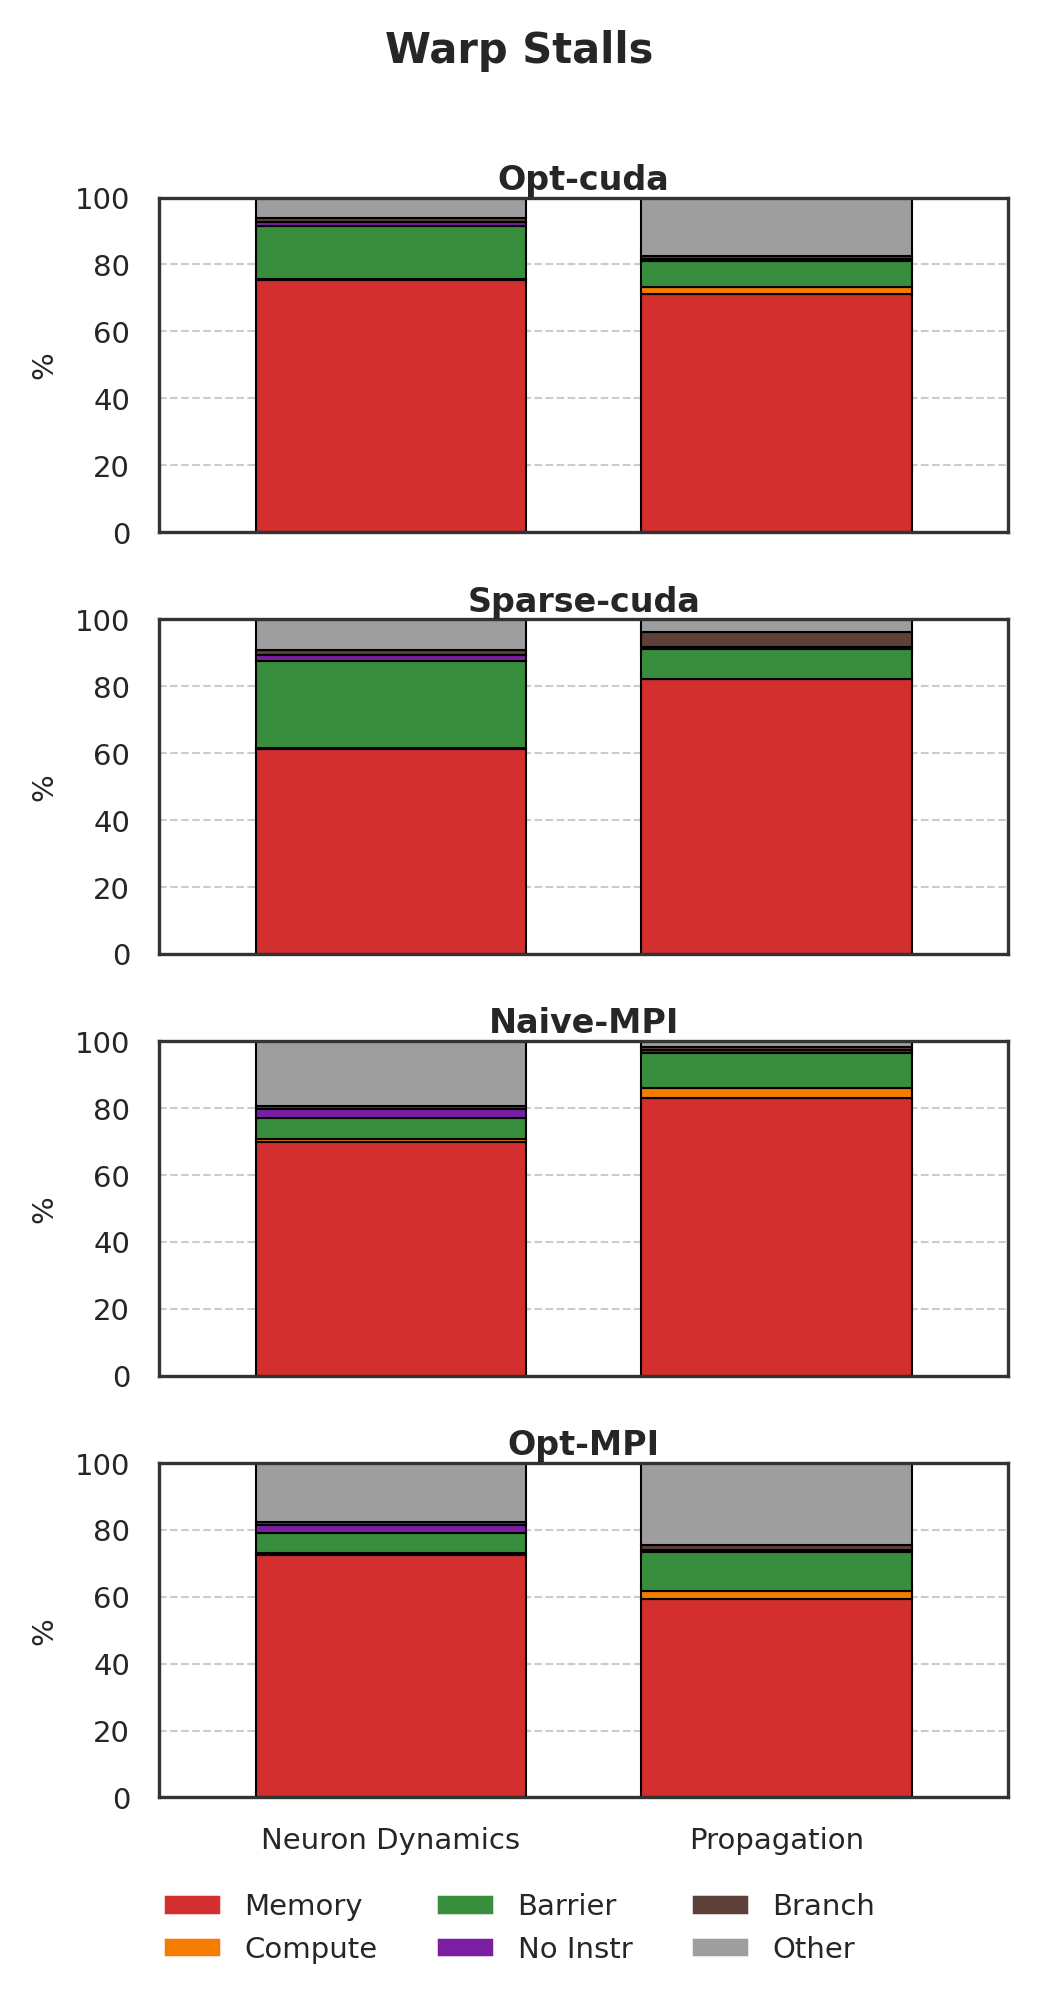

In [94]:
# Key stall metrics
STALL_METRICS = {
    'smsp__warp_issue_stalled_long_scoreboard_per_warp_active.pct': 'Memory',
    'smsp__warp_issue_stalled_short_scoreboard_per_warp_active.pct': 'Compute',
    'smsp__warp_issue_stalled_wait_per_warp_active.pct': 'Barrier',
    'smsp__warp_issue_stalled_no_instruction_per_warp_active.pct': 'No Instr',
    'smsp__warp_issue_stalled_branch_resolving_per_warp_active.pct': 'Branch'
}

stall_data = []

for impl in target_impls:
    metrics_path = NCU_DIR / impl / "snp_profile_metrics.csv"
    if not metrics_path.exists():
        candidates = list((NCU_DIR / impl).glob("*rank0_metrics.csv"))
        if candidates:
            metrics_path = candidates[0]
        else:
            continue
    
    try:
        df = pd.read_csv(metrics_path, header=0, skiprows=[1])
        df.columns = [c.replace('"', '').strip() for c in df.columns]
        df['Kernel Name'] = df['Kernel Name'].str.replace('"', '').str.strip()
        
        def clean_name(name):
            if '(' in name: name = name.split('(')[0]
            if '::' in name: name = name.split('::')[-1]
            return name.strip()
        
        df['CleanName'] = df['Kernel Name'].apply(clean_name)
        df['Functionality'] = df['CleanName'].map(KERNEL_FUNCTION_MAP).fillna('Other')
        
        if 'gpu__time_duration.sum' not in df.columns:
            continue
        
        df['Duration'] = pd.to_numeric(df['gpu__time_duration.sum'], errors='coerce').fillna(0)
        
        for col, label in STALL_METRICS.items():
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
                df[f'{label}_weighted'] = df[col] * df['Duration']
        
        agg_dict = {f'{label}_weighted': 'sum' for label in STALL_METRICS.values()}
        agg_dict['Duration'] = 'sum'
        grouped = df.groupby('Functionality')[list(agg_dict.keys())].sum()
        
        for func in ['Neuron Dynamics', 'Propagation', 'MPI Communication']:
            if func in grouped.index:
                total_dur = grouped.loc[func, 'Duration']
                if total_dur > 0:
                    total_stall = 0.0
                    display_name = impl.replace('cuda-mpi', 'MPI').replace('-linear', '')
                    display_name = display_name.replace('optimized', 'Opt').replace('naive', 'Naive').replace('sparse', 'Sparse')
                    
                    for label in STALL_METRICS.values():
                        weighted = grouped.loc[func, f'{label}_weighted']
                        avg_pct = weighted / total_dur
                        total_stall += avg_pct
                        
                        stall_data.append({
                            'Implementation': display_name,
                            'Functionality': func,
                            'Stall': label,
                            'Percentage': avg_pct
                        })
                    
                    stall_data.append({
                        'Implementation': display_name,
                        'Functionality': func,
                        'Stall': 'Other',
                        'Percentage': max(0, 100.0 - total_stall)
                    })
    
    except Exception as e:
        print(f"⚠ Error processing {impl}: {e}")

if stall_data:
    df_stall = pd.DataFrame(stall_data)
    
    # Stall colors (semantic)
    stall_colors = {
        'Memory': '#D32F2F',      # Red (critical)
        'Compute': '#F57C00',     # Orange
        'Barrier': '#388E3C',     # Green
        'No Instr': '#7B1FA2',   # Purple
        'Branch': '#5D4037',           # Brown
        'Other': '#9E9E9E'             # Grey
    }
    
    implementations = df_stall['Implementation'].unique()
    n_impls = len(implementations)
    
    # Vertical stack 
    fig, axes = plt.subplots(n_impls, 1, figsize=(SINGLE_COL_WIDTH, 5.5 * CHART_HEIGHT_SCALE), sharex=True)
    if n_impls == 1: axes = [axes]
    
    for idx, impl in enumerate(implementations):
        ax = axes[idx]
        impl_data = df_stall[df_stall['Implementation'] == impl]
        
        pivot = impl_data.pivot(index='Functionality', columns='Stall', values='Percentage').fillna(0)
        cols = [c for c in stall_colors.keys() if c in pivot.columns]
        pivot = pivot[cols]
        
        pivot.plot(kind='bar', stacked=True, ax=ax,
                  color=[stall_colors[c] for c in pivot.columns],
                  edgecolor='black', linewidth=0.5, width=0.7, legend=False)
        
        ax.set_title(impl, fontweight='bold', fontsize=8, pad=2)
        ax.set_xlabel('')
        ax.set_ylabel('%', fontsize=7)
        ax.tick_params(axis='x', rotation=0)
        ax.set_ylim([0, 100])
    
    # Consolidated legend at bottom
    handles = [plt.Rectangle((0,0),1,1, facecolor=stall_colors[s], edgecolor=None) 
              for s in stall_colors.keys()]
    fig.legend(handles, list(stall_colors.keys()), 
              loc='lower center', bbox_to_anchor=(0.5, 0.0), 
              ncol=3, frameon=False)
    
    fig.suptitle('Warp Stalls', fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    plt.show()
else:
    print("⚠ No stall data available")

---
## Summary

All visualizations have been generated with improved styling:

✓ **Enhanced Readability**
- Larger, clearer fonts
- Better color contrasts
- Consistent styling across all figures

✓ **Professional Appearance**
- Colorblind-friendly palettes
- Clean grid lines and borders
- Proper spacing and alignment

✓ **Improved Legends**
- All legends positioned below charts
- Consolidated legends for multi-subplot figures
- Clear, readable labels

**Figures Generated:**
1. Scaling Performance (Speedup Analysis)
2. Distribution Stability Analysis
3. Execution Time Breakdown
4. Partitioning Strategy Impact
5. Kernel Functionality Breakdown
6. Memory Hierarchy Utilization
7. Warp Stall Analysis